In [1]:
import numpy as np
import seaborn as sns
import sklearn
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = sns.load_dataset('titanic')

family = dataset.loc[:,'sibsp'].add(dataset.loc[:,'parch'])
family = pd.DataFrame(family, columns=['family'])

dataset = dataset.join(family)
print("The dataset: ", end='\n\n')
print(dataset)



column_names = np.array(dataset.columns)
data = dataset.values
data = np.array([row for row in data if (not np.isnan(row[3]))])


The dataset: 

     survived  pclass     sex   age  sibsp  parch     fare embarked   class  \
0           0       3    male  22.0      1      0   7.2500        S   Third   
1           1       1  female  38.0      1      0  71.2833        C   First   
2           1       3  female  26.0      0      0   7.9250        S   Third   
3           1       1  female  35.0      1      0  53.1000        S   First   
4           0       3    male  35.0      0      0   8.0500        S   Third   
..        ...     ...     ...   ...    ...    ...      ...      ...     ...   
886         0       2    male  27.0      0      0  13.0000        S  Second   
887         1       1  female  19.0      0      0  30.0000        S   First   
888         0       3  female   NaN      1      2  23.4500        S   Third   
889         1       1    male  26.0      0      0  30.0000        C   First   
890         0       3    male  32.0      0      0   7.7500        Q   Third   

       who  adult_male deck  embark_

## Exploration of features

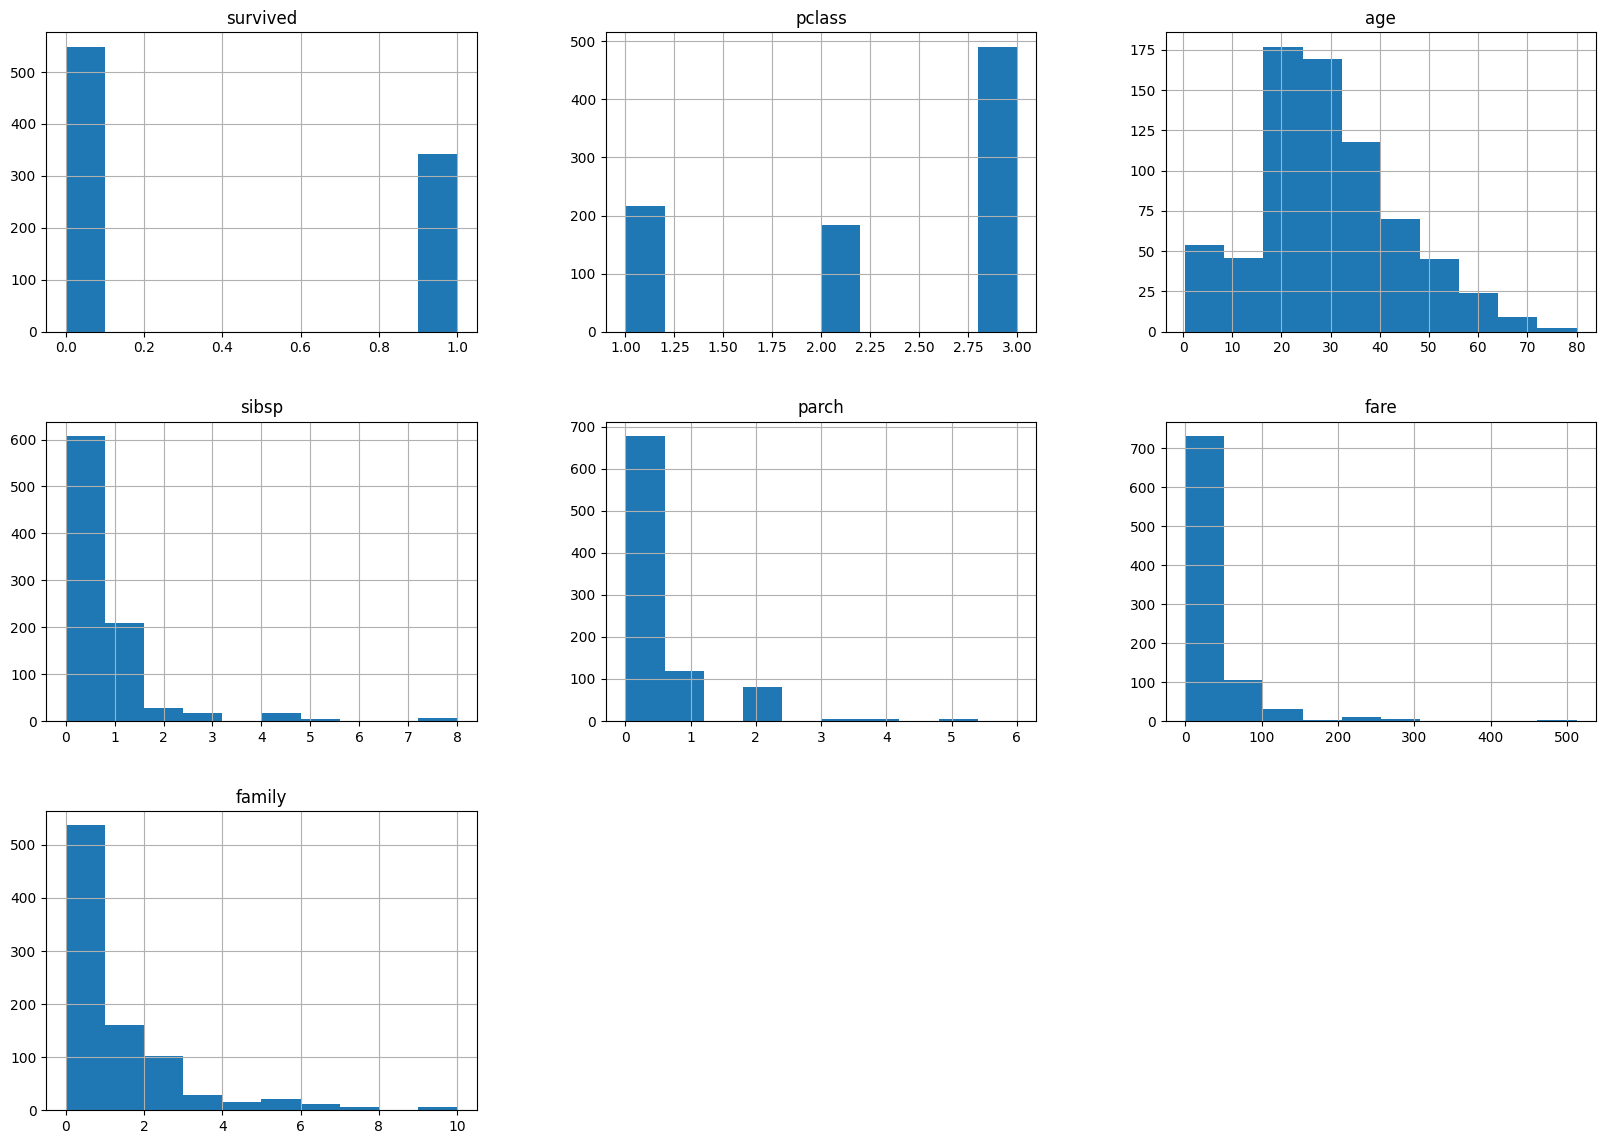

In [14]:
_ = dataset.hist(figsize=(20, 14))

### Survivors Male vs Female

Amount of female-survivors is *2 time bigger* than amount of male-survivors, since women are a priority.

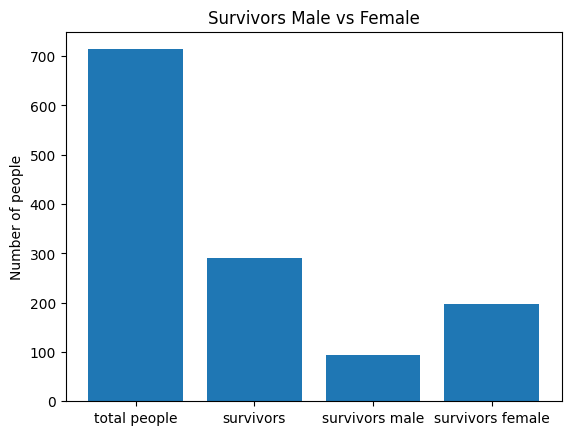

In [12]:
total_people = data.shape[0]
total_survivors = sum(data[:, 0])
total_survivors_male = sum(row[0] for row in data if row[2] == 'male')
total_survivors_female = sum(row[0] for row in data if row[2] == 'female')

plt.bar(['total people', 'survivors', 'survivors male', 'survivors female'],
        [total_people, total_survivors, total_survivors_male, total_survivors_female])
plt.ylabel('Number of people')
_ = plt.title('Survivors Male vs Female')
        

### Age distribution

Young and healthy people had better chances at survival than old. 
Also old could have given their places on boats to younger people,
who have a long live ahead or a family, that depends on them.




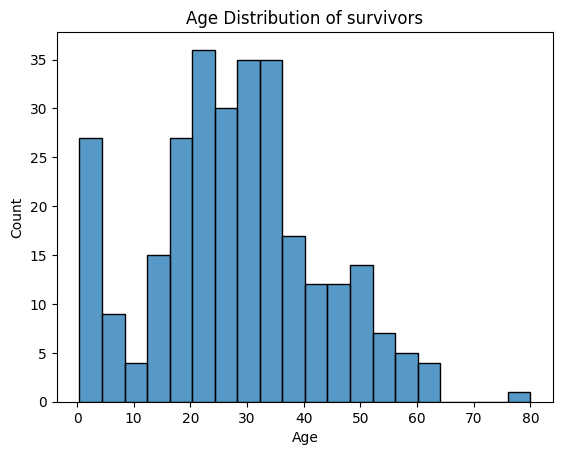

In [16]:
ages = [row[3] for row in data if row[0] == 1]

sns.histplot(ages, bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
_ = plt.title("Age Distribution of survivors")

### Survivors' wealth

The more wealth you have, the better chances of survival you have.

The reason could be, that better classes are nearer to the surface, where people had much better chances of getting out alive.

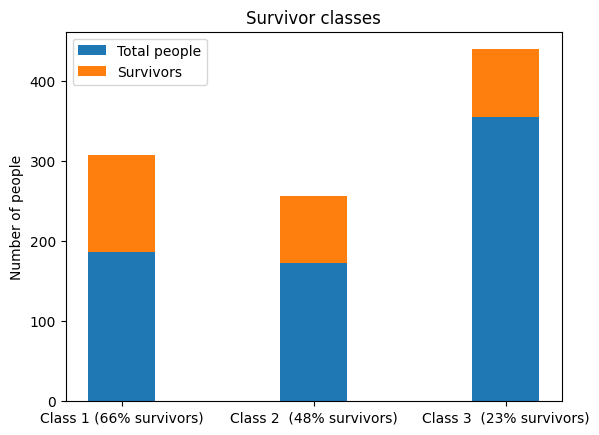

In [11]:
first_class_total = sum([1 for row in data if row[1] == 1])
second_class_total = sum([1 for row in data if row[1] == 2])
third_class_total = sum([1 for row in data if row[1] == 3])

first_class_survivors = sum([row[0] for row in data if row[1] == 1])
second_class_survivors = sum([row[0] for row in data if row[1] == 2])
third_class_survivors = sum([row[0] for row in data if row[1] == 3])

percentage1 = int(round(first_class_survivors /  first_class_total, 2) * 100)
percentage2 = int(round(second_class_survivors /  second_class_total, 2) * 100)
percentage3 = int(round(second_class_survivors /  third_class_total, 2) * 100)

width = 0.35

plt.bar(['Class 1 (' + str(percentage1) + '% survivors)', 'Class 2  (' + str(percentage2) + '% survivors)', 'Class 3  (' + str(percentage3) + '% survivors)'],
        [first_class_total, second_class_total, third_class_total],
        width,
        label='Total people',)
plt.bar(['Class 1 (' + str(percentage1) + '% survivors)', 'Class 2  (' + str(percentage2) + '% survivors)', 'Class 3  (' + str(percentage3) + '% survivors)'],
        [first_class_survivors, second_class_survivors, third_class_survivors],
        width,
        bottom = [first_class_total, second_class_total, third_class_total],
        label='Survivors')

plt.ylabel('Number of people')
plt.title('Survivor classes')
_ = plt.legend()

### Feature correlation


Features, that correlate the most with survival chances are:
- Passenger class
- Age
- Amount of children and parents
- Fare
- Adult male
- Being alone

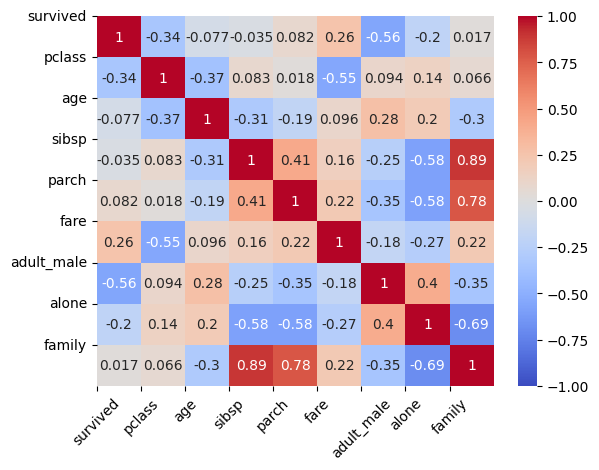

In [6]:
corr = dataset.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)


plt.show()

## Train model to predict survival

### Model Selection

We need to predict binary value, so let's try Logistic Regression first.